In [1]:
%reset -f 

from LadrunoGraphStyle import set_default_plot_params, main_colors
set_default_plot_params()

In [2]:
from ShakerMakerResults import ShakerMakerData

import numpy as np
import os

import h5py
import matplotlib.pyplot as plt


  ShakerMakerResults -- Visualization and Analysis Toolkit
  Built on top of Shakermaker Tool

  Version 1.0.0                        (c) 2026 All Rights Reserved

  Repository  :  https://github.com/ppalacios92/ShakerMakerResults
  ShakerMaker :  https://github.com/ppalacios92/ShakerMaker

  Patricio Palacios B. | Nicolás Mora Bowen | José Abell | Ladruno Team
  
  ********* (>'-')> Ladruno4ever  *********



## Surface simple

In [3]:
folder= '/home/pxpalacios/Dropbox/resources/Gaussian_Perturbation_topo'
# folder = r'C:\Dropbox\resources\Gaussian_Perturbation_topo'

h5drm = os.path.join(folder, 'Gaussian_Perturbation_topo.h5drm')

surface_gaussian = ShakerMakerData(h5drm)



  vmax cache loaded from sidecar.
----------------------------------------------------------------------------------------------------
ShakerMakerData  :  /home/pxpalacios/Dropbox/resources/Gaussian_Perturbation_topo/Gaussian_Perturbation_topo.h5drm
  Type     : DRM
  Model    : 100.0m  |  Spacing: 100.0m x 100.0m x 11.7m
  Domain   : Lx=30000.0m  Ly=30000.0m  Lz=1500.0m
  Nodes    : 90601  |  Internal: 90601  |  External: 0
  QA       : yes  ->  [15000. 15000.     0.] m
  Time     : dt=0.013157894736842105s  |  steps=685  |  t=[0.000, 9.013]s
  GF       : steps=0  |  not loaded
  RAM      : 7.1 GB used  |  25.7 GB free  |  21.7%
  File size:
    acceleration         (271803, 685)  1.49 GB
    displacement         (271803, 685)  1.49 GB
    velocity             (271803, 685)  1.49 GB
    xyz                  (90601, 3)  0.00 GB
    TOTAL                             4.47 GB
----------------------------------------------------------------------------------------------------



----------------------------------------------------------------------------------------------------
Resample
  Data dt  : 0.013158s -> 0.010000s
  Data     : 685 -> 900 samples
  Time     : [0.000, 9.000] s unchanged
  GF       : not loaded
----------------------------------------------------------------------------------------------------

--------------------------------------------------
NODE INFO
  QA       │ pos = [  15000.00,   15000.00,       0.00] m
--------------------------------------------------


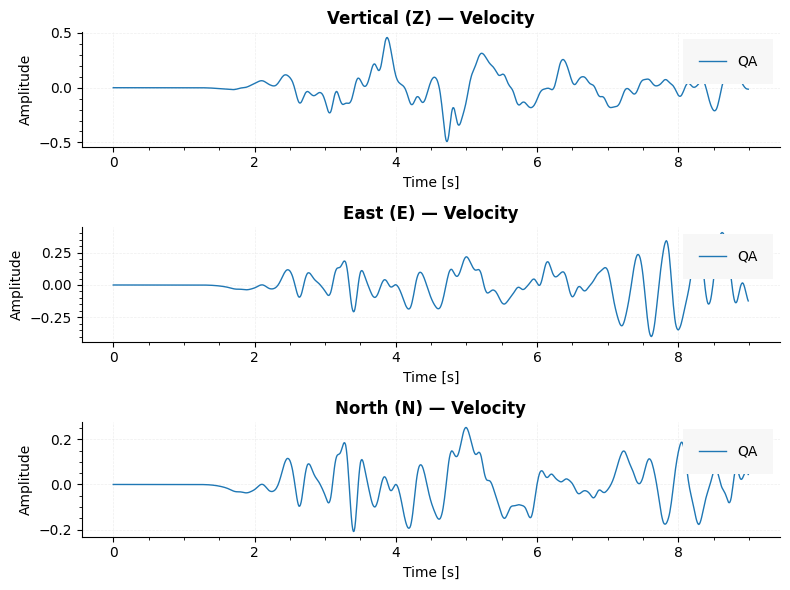

In [4]:
# resample 
surface_gaussian_resample = surface_gaussian.resample(dt=0.01)
surface_gaussian_resample.plot_node_response(
                                node_id='QA', 
                                data_type='vel', 
                                figsize=(8, 6),
                                factor=1.0,
                                )

----------------------------------------------------------------------------------------------------
Window   : /home/pxpalacios/Dropbox/resources/Gaussian_Perturbation_topo/Gaussian_Perturbation_topo.h5drm
  Range  : [0.000, 10.000] s
  Data   : 685 -> 685 samples
  Time   : [0.000, 9.000] -> [0.000, 9.000] s
----------------------------------------------------------------------------------------------------

--------------------------------------------------
NODE INFO
  N70042  │ pos = [  21000.00,   23200.00,     218.31] m │ internal
  Target   │ pos = [  21000.00,   23000.00,       0.00] m │ dist = 296.08 m
--------------------------------------------------


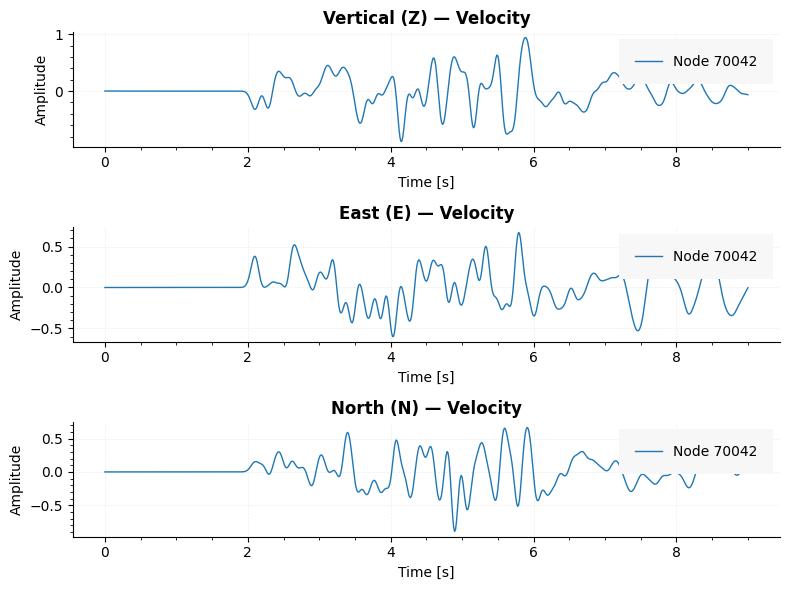

In [5]:
# get_window

surface_gaussian_window= surface_gaussian.get_window(t_start=0.0, t_end=10.0)

surface_gaussian_window.plot_node_response(
                                target_pos=[6+15 , 8+15,  0.00],
                                data_type='vel', 
                                figsize=(8, 6),
                                factor=1.0,
                                )

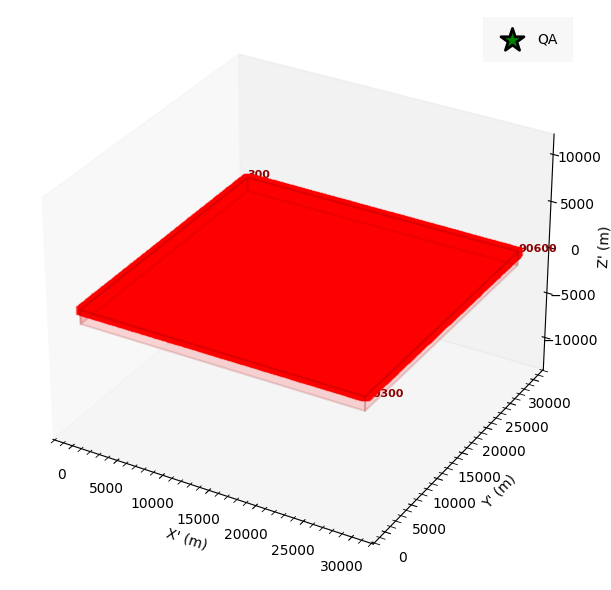

QA position: [15000. 15000.     0.]


(<Figure size 800x600 with 1 Axes>,
 <Axes3D: xlabel="X' (m)", ylabel="Y' (m)", zlabel="Z' (m)">)

In [6]:
surface_gaussian_window.plot_domain( 
    xyz_origin=None,
    label_nodes='corners',
    show_calculated=False,
    figsize=(8, 6),
    axis_equal=True,
)

In [7]:
surface_gaussian_window.plot_domain_calculated_t0(
    subfault='all',
    xyz_origin=None,
    show_calculated_only=True,
    figsize=(8, 6),
    axis_equal=True,
    cmap="viridis",
)

GF not loaded.


In [8]:
surface_gaussian_window.plot_gf_connections(
                        node_id='QA',
                        xyz_origin=None,
                        label_nodes='donor_receivers',
                        figsize=(8,6),
                        axis_equal=True)  

No GFs. Call load_gf_database() first.


--------------------------------------------------
NODE INFO
  QA       │ pos = [  15000.00,   15000.00,       0.00] m
  N0      │ pos = [      0.00,       0.00,       0.00] m │ internal
  N100    │ pos = [  10000.00,       0.00,       0.00] m │ internal
--------------------------------------------------


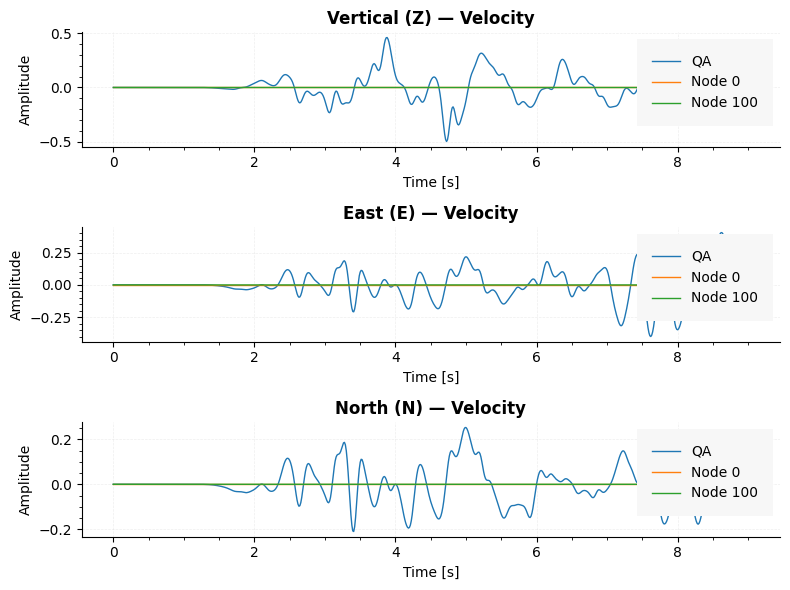

In [9]:
# Por ID
surface_gaussian_window.plot_node_response( 
                        node_id=['QA' , 0,100], 
                        data_type='vel', 
                        figsize=(8, 6),
                        factor=1.0,
                        )

--------------------------------------------------
NODE INFO
  QA       │ pos = [  15000.00,   15000.00,       0.00] m
  N0      │ pos = [      0.00,       0.00,       0.00] m │ internal
  N100    │ pos = [  10000.00,       0.00,       0.00] m │ internal
--------------------------------------------------


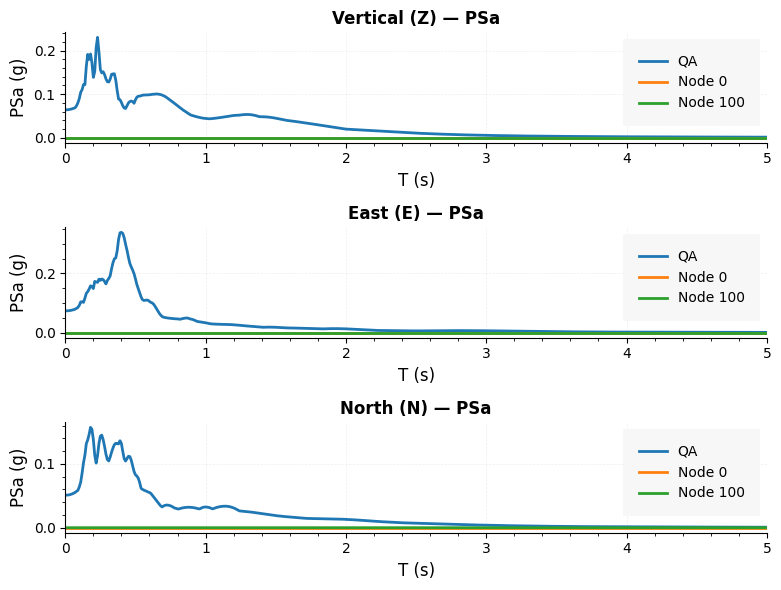

In [10]:
# Por ID
surface_gaussian_window.plot_node_newmark( 
                        node_id=['QA' , 0,100], 
                        data_type='accel', 
                        spectral_type='PSa',
                        figsize=(8, 6),
                        factor=1/9.81,
                        )

In [11]:
surface_gaussian_window.plot_node_tensor_gf(
                        node_id=['QA'],
                        subfault=0, 
                        figsize=(8, 6),
                        )

No GFs. Call load_gf_database() first.


--------------------------------------------------
NODE INFO
  QA       │ pos = [  15000.00,   15000.00,       0.00] m
  N0      │ pos = [      0.00,       0.00,       0.00] m │ internal
  N100    │ pos = [  10000.00,       0.00,       0.00] m │ internal
--------------------------------------------------


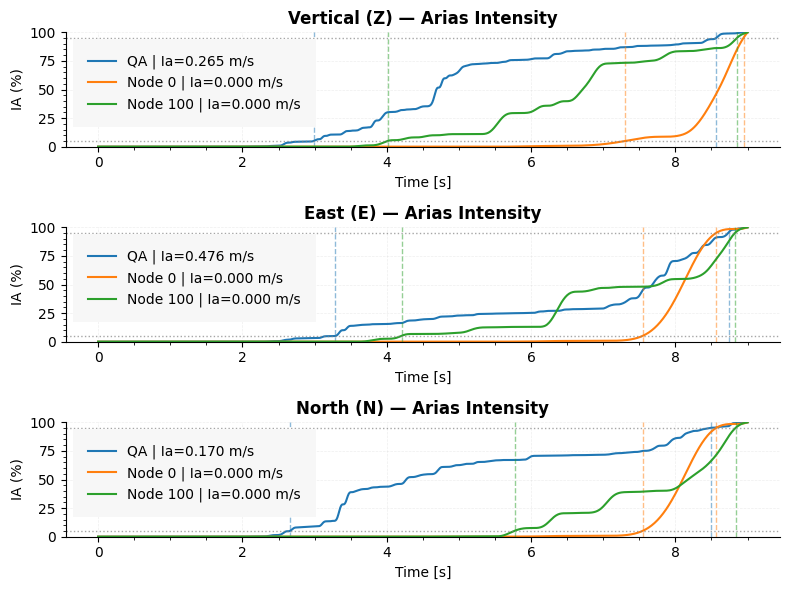

In [12]:
surface_gaussian_window.plot_node_arias(              
                    node_id=['QA' , 0,100],
                    data_type     = 'accel',
                    figsize=(8, 6),
                    factor=1,
                    )

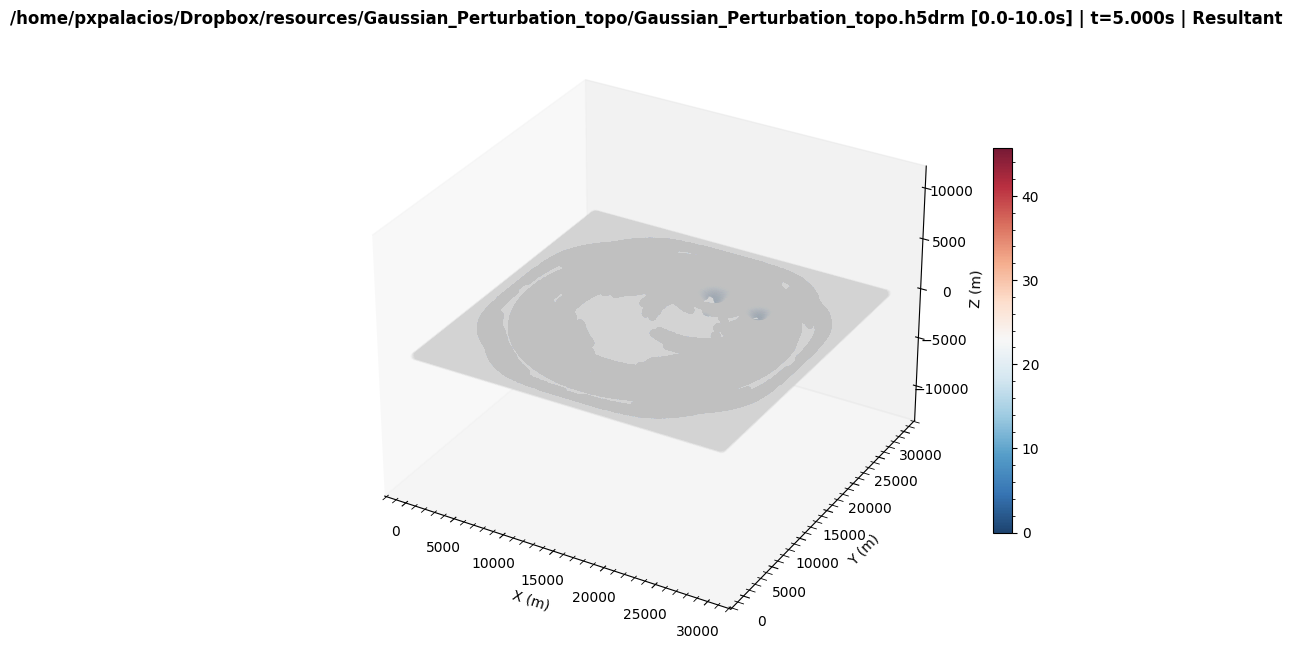

In [13]:
# Plot surface snapshot
surface_gaussian_window.plot_surface(  time=5.0, 
                            component='resultant', 
                            data_type='vel', 
                            cmap='RdBu_r', 
                            figsize=(8, 8),
                            elev=30, azim=-60, s=20, alpha=0.9,
                            axis_equal=True,)
    

In [14]:
# surface_gaussian_window.plot_surface_newmark(
#                         T_target      = 0.0,
#                         component     = 'resultant',
#                         data_type     = 'accel',
#                         spectral_type = 'PSa',
#                         factor        = 1.0/9.81,
#                         cmap          = 'viridis',
#                         figsize       = (8, 6),
#                         # elev          = 35,
#                         # azim          = -60,
#                         s             = 20,
#                         alpha         = 0.85,
#                         axis_equal    = True,
#                         n_jobs        = -2,
# )

In [15]:
# surface_gaussian_window.plot_surface_arias(
#                     component  = 'z',
#                     data_type  = 'accel',
#                     factor     = 1.0,
#                     cmap       = 'turbo',
#                     figsize       = (8, 6),
#                     elev          = 35,
#                     azim          = -60,
#                     s          = 20,
#                     alpha      = 0.85,
#                     axis_equal = True,
#                     n_jobs     = -2,
# )

In [16]:
surface_gaussian_window.viewer()